In [1]:
# Core
import os
import pandas as pd
import copy
import numpy as np
import pybedtools

# Graphs
import matplotlib.pyplot as plt
import seaborn as sns
# Statistics
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
from scipy.stats import mannwhitneyu
from itertools import combinations
from scipy.stats import binomtest
from adjustText import adjust_text
from sklearn.metrics import precision_recall_curve
from scipy.stats import spearmanr
from scipy.stats import pearsonr

from scipy.stats import ks_2samp # Kolmogorov–Smirnov (KS)
from scipy.stats import linregress
from scipy.stats import gaussian_kde


/home/labs/davidgo/nadavmi/.conda/envs/Nadav_python/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.stats import gaussian_kde


In [2]:
os.chdir('/home/labs/davidgo/nadavmi/backup')

#import importlib
#importlib.reload(const)

import const #to reload use import(importlib) and then importlib.reload(const)
from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
from const import set_equal_plot_limits
from const import plot_color_pallete
from const import custom_cmap_bolder
from const import FONT_SIZE_small
from const import save_fig
const.set_plot_style()

os.chdir('/home/labs/davidgo/Collaboration')

In [3]:
# Parameters
filter_for_oligos_w_1_variant = False
fig_dir ='humanMPRA/TF_analysis/final/figures'
dataset_dir = 'humanMPRA/TF_analysis/final/datasets_for_paper'

In [4]:
# Load MPRA results
MPRA_output= pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv', 
                     header=0)

MPRA_output.rename(columns={'oligo':'seq_id',}, inplace=True)

# Add fields
MPRA_output['active_bool'] = MPRA_output['differential_activity'].isin([True, False])
MPRA_output['diff_active_bool'] = MPRA_output['differential_activity']==True

#keep only relevant fields
MPRA_output = MPRA_output[['seq_id','variants_genomic','variants_count','logFC_derived_vs_ancestral','activity_fdr_ancestral',
                           'activity_fdr_derived','differential_activity_fdr','active_bool','diff_active_bool']]


if filter_for_oligos_w_1_variant:
    print(f"Filtering for oligos with exactly 1 variant. Original count: {len(MPRA_output)}, Filtered count: {len(MPRA_output[MPRA_output['variants_count'] == 1])}")
    MPRA_output = MPRA_output[MPRA_output['variants_count'] == 1]


/tmp/ipykernel_2833911/3220943073.py:2: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  MPRA_output= pd.read_csv(f'/home/labs/davidgo/Collaboration/humanMPRA/top_candidates/chondrocytes/humanMPRA_annotations_v3.csv',


In [5]:
# Load FIMO and PBM results
hMPRA_PBM = pd.read_csv(f'humanMPRA/TF_analysis/final/results/hMPRA_PBM_oligo_TF_merged.tsv', sep='\t')
hMPRA_PBM['motif_id_clean'] = hMPRA_PBM['motif_id_clean'].str.upper()

hMPRA_FIMO = pd.read_csv(f'humanMPRA/TF_analysis/final/results/hMPRA_FIMO_oligo_TF_merged.tsv', sep='\t')
hMPRA_FIMO['motif_id_clean'] = hMPRA_FIMO['motif_id_clean'].str.upper()


## Neither is in PBM

In [38]:
TFs_of_interest = ['ZFP42'] # Alternatives


In [39]:
path = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Sequence/Motifs_and_TFBS/PBM/data/pbm_8mer_data.pkl"
pbm_data = pd.read_pickle(path)

TFs_of_interest = ['ZFAT', 'ZFHX4', 'ZNF18'] # The original ones
TFs_of_interest = ['ZFP42'] # Alternatives


found = any(
    s.lower() in key.lower()
    for key in pbm_data
    for s in TFs_of_interest
)

print(found)

False


In [36]:
jaspar_metadata = pd.read_csv('USEFUL_DATASETS/Sequence/Motifs_and_TFBS/JASPAR2024/JASPAR2024_CORE_vertebrates_non-redundant_meta.tsv', 
                     header=0,sep = '\t')
jaspar_metadata = jaspar_metadata.rename(columns={'Unnamed: 0': 'Matrix_ID'})

jaspar_metadata['TF'] = jaspar_metadata['TF'].str.upper()

In [40]:
#check if TFs of interest are in JASPAR
found_in_jaspar = any(
    s in jaspar_metadata['TF'].values
    for s in TFs_of_interest        
)

print(found_in_jaspar)

True


In [34]:
TFs_of_interest

['ZNF841']

In [24]:
jaspar_metadata[jaspar_metadata['Matrix_ID']=='MA2590.1']

,Unnamed: 0.1,Matrix_ID,TF,TF_family,TF_class,pubmed_ids,uniprot_ids,experiment_type,motif_width,nsites,E-value,PFM,PWM (Background letter frequencies = 0.25),url,main


In [50]:
jaspar_metadata

,Unnamed: 0.1,Matrix_ID,TF,TF_family,TF_class,pubmed_ids,uniprot_ids,experiment_type,motif_width,nsites,E-value,PFM,PWM (Background letter frequencies = 0.25),url,main
0,0,MA0004.1,ARNT,PAS domain factors,Basic helix-loop-helix factors (bHLH),7592839,P53762,SELEX,6,20,0.0,"[[4.0, 16.0, 0.0, 0.0], [19.0, 0.0, 1.0, 0.0],...","{'A': [0.2, 0.95, 0.0, 0.0, 0.0, 0.0], 'C': [0...",http://jaspar.genereg.net/matrix/MA0004.1,True
1,1,MA0069.1,PAX6,Paired plus homeo domain,Paired box factors,8132558,P26367,SELEX,14,43,0.0,"[[2.0, 4.0, 4.0, 33.0], [2.0, 2.0, 0.0, 39.0],...","{'A': [0.046512, 0.046512, 0.093023, 0.906977,...",http://jaspar.genereg.net/matrix/MA0069.1,True
2,2,MA0071.1,RORA,Thyroid hormone receptor-related factors (NR1),Nuclear receptors with C4 zinc fingers,7926749,P35398,SELEX,10,25,0.0,"[[15.0, 1.0, 2.0, 7.0], [9.0, 1.0, 0.0, 15.0],...","{'A': [0.6, 0.36, 0.24, 0.44, 0.84, 0.0, 0.0, ...",http://jaspar.genereg.net/matrix/MA0071.1,False
3,3,MA0074.1,RXRA::VDR,RXR-related receptors (NR2); Thyroid hormone r...,Nuclear receptors with C4 zinc fingers; Nuclea...,8674817,P11473; P19793,SELEX,15,10,0.0,"[[3.0, 0.0, 7.0, 0.0], [0.0, 0.0, 10.0, 0.0], ...","{'A': [0.3, 0.0, 0.0, 0.0, 0.0, 0.9, 0.4, 0.2,...",http://jaspar.genereg.net/matrix/MA0074.1,True
4,4,MA0101.1,REL,NF-kappaB-related factors,Rel homology region (RHR) factors,1406630,Q04864,SELEX,10,17,0.0,"[[0.0, 5.0, 8.0, 4.0], [0.0, 1.0, 15.0, 1.0], ...","{'A': [0.0, 0.0, 0.058824, 0.294118, 0.352941,...",http://jaspar.genereg.net/matrix/MA0101.1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
874,874,MA1628.2,ZIC1::ZIC2,More than 3 adjacent zinc fingers; More than 3...,C2H2 zinc finger factors,11038359,P46684; Q62520,ChIP-seq,7,9892,0.0,"[[29.0, 9594.0, 106.0, 163.0], [9238.0, 384.0,...","{'A': [0.002932, 0.933886, 0.009705, 0.007582,...",http://jaspar.genereg.net/matrix/MA1628.2,True
875,875,MA1629.2,ZIC2,More than 3 adjacent zinc fingers,C2H2 zinc finger factors,11038359,Q62520,ChIP-seq,9,11919,0.0,"[[1161.0, 9933.0, 585.0, 240.0], [6888.0, 1765...","{'A': [0.097408, 0.577901, 0.011326, 0.929105,...",http://jaspar.genereg.net/matrix/MA1629.2,True
876,876,MA0697.3,ZIC3,More than 3 adjacent zinc fingers,C2H2 zinc finger factors,20872845; 19443739,Q62521,NaN,7,26174,0.0,"[[345.0, 25035.0, 460.0, 334.0], [23947.0, 872...","{'A': [0.013181, 0.914916, 0.012646, 0.013525,...",http://jaspar.genereg.net/matrix/MA0697.3,True
877,877,MA0619.2,LIN54,tesmin/TSO1-family,CRC domain,19725879,A0A8V0XB38,PBM,7,999,0.0,"[[0.0, 0.0, 0.0, 999.0], [0.0, 0.0, 0.0, 999.0...","{'A': [0.0, 0.0, 0.0, 0.438, 1.0, 1.0, 0.104],...",http://jaspar.genereg.net/matrix/MA0619.2,True


In [7]:
all_motifs = pd.concat([hMPRA_PBM, hMPRA_FIMO], axis = 0)

In [8]:
merged_df = pd.merge(all_motifs, MPRA_output, on='seq_id', how='outer')
PBM_merged_df = pd.merge(hMPRA_PBM, MPRA_output, on='seq_id', how='outer')
FIMO_merged_df = pd.merge(hMPRA_FIMO, MPRA_output, on='seq_id', how='outer')

In [27]:
FIMO_TFs = hMPRA_FIMO['motif_id_clean'].unique()
PBM_TFs = hMPRA_PBM['motif_id_clean'].unique()

In [30]:
TFs_of_interest = ['ZFAT', 'ZFHX4', 'ZNF18']
for tf in TFs_of_interest:
    if tf in FIMO_TFs:
        print(f"{tf} is in FIMO_TFs")
    else:
        print(f"{tf} is NOT in FIMO_TFs")

for tf in TFs_of_interest:
    if tf in PBM_TFs:
        print(f"{tf} is in PBM_TFs")
    else:
        print(f"{tf} is NOT in PBM_TFs")

ZFAT is NOT in FIMO_TFs
ZFHX4 is NOT in FIMO_TFs
ZNF18 is NOT in FIMO_TFs
ZFAT is NOT in PBM_TFs
ZFHX4 is NOT in PBM_TFs
ZNF18 is NOT in PBM_TFs


In [27]:
gene_annotation_table = pd.read_csv('/home/labs/davidgo/nadavmi/usefull/Human.GRCh38.p13.annot.tsv', 
                     header=0,sep = '\t',usecols=[0,1])


articular_cartilage_TPM = pd.read_csv('/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/Cartilage/Human/GSE114007_human_control_and_osteoarithritis_cartilage/GSE114007_norm_counts_TPM_GRCh38.p13_NCBI.tsv', 
                     header=0,sep = '\t')

articular_cartilage_TPM = articular_cartilage_TPM.iloc[:,0:9]
articular_cartilage_TPM['articular_cartilage_mean'] = articular_cartilage_TPM.iloc[:, 1:].mean(axis=1)
articular_cartilage_TPM = articular_cartilage_TPM[['GeneID','articular_cartilage_mean']]


articular_cartilage_TPM = pd.merge(articular_cartilage_TPM, gene_annotation_table, on='GeneID', how='outer') 
articular_cartilage_TPM = articular_cartilage_TPM.set_index('Symbol')
articular_cartilage_TPM = articular_cartilage_TPM[['articular_cartilage_mean']]
articular_cartilage_TPM = articular_cartilage_TPM.groupby('Symbol', as_index=True).mean() # Group by gene name and average duplicates


In [ ]:
articular_cartilage_TPM[articular_cartilage_TPM.index.isin(['ZFP42'])]

,articular_cartilage_mean
Symbol,
ZFP42,0.071569


: 

In [26]:
articular_cartilage_TPM[articular_cartilage_TPM.index.isin(['ZFAT', 'ZFHX4', 'ZNF18'])]

,articular_cartilage_mean
Symbol,
ZFAT,1.156525
ZFHX4,3.720250
ZNF18,0.899288


## Comparing positive controls in hMPRA chonds to original oligos in mhMPRA  (osteoblats only). Check (1) Similar direction and (2) correlation.

In [82]:
mhMPRA_dir = "/home/labs/davidgo/Collaboration/USEFUL_DATASETS/Expression/MPRAs/Modern human derived MPRA/comparative_df_Hob.csv"
mhMPRA_df = pd.read_csv(mhMPRA_dir, header=0)
mhMPRA_df["seq"] = mhMPRA_df['Sequence ID'].str.extract(r"(seq\d+)", expand=False)
mhMPRA_df = mhMPRA_df[['Sequence ID', 'seq', 'logFC','differentialy_active']]


In [110]:
libraries = [
    #"L3a3",
     "L1a1", "L1a2", "L1a3",
     "L2a1", "L2a2", "L2a3",
     "L3a1", "L3a2", "L3a3",
     "L4a1",
]

base_dir = "/home/labs/davidgo/Collaboration/humanMPRA/chondrocytes"
rel_path = "output/mpranalyze_comparative/posctrl/mpranalyze_comp_res_filter_sorted.txt"

dfs = []
percents = []

for lib in libraries:
    positive_controls_dir = os.path.join(base_dir, lib, rel_path)
    df = pd.read_csv(positive_controls_dir, sep="\t")
    df["library"] = lib
    print(lib)

    successful_controls = (df["fdr"] < 0.05).sum()
    total_controls = len(df)

    pct = (successful_controls / total_controls) * 100 if total_controls else float("nan")
    percents.append(pct)

    dfs.append(df)

positive_controls = pd.concat(dfs, ignore_index=False)

L1a1
L1a2
L1a3
L2a1
L2a2
L2a3
L3a1
L3a2
L3a3
L4a1


In [86]:
positive_controls_ost = positive_controls[positive_controls.index.str.contains("ost", case=False, na=False)].copy()

positive_controls_ost["seq"] = positive_controls_ost.index.to_series().str.extract(r"(seq\d+)", expand=False)

positive_controls_ost = positive_controls_ost[["seq", "logFC", "fdr", "library"]].copy()

In [87]:
positive_controls_ost

,seq,logFC,fdr,library
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq119140_a1_L1,seq119140,-0.016597,0.608607,L1a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq67771_a1_L1,seq67771,0.147209,0.000258,L1a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq44930_a1_L1,seq44930,-0.125844,0.007209,L1a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq14238_a1_L1,seq14238,0.084128,0.073395,L1a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq209775_a1_L1,seq209775,0.131326,0.002014,L1a1
...,...,...,...,...
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq4513_a1_L4,seq4513,-0.601737,0.639909,L4a1
PosCtrl_diff_Osteoblasts_Weiss_seq311144_a1_L4,seq311144,NaN,0.000000,L4a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq95523_a1_L4,seq95523,0.130082,1.000000,L4a1
PosCtrl_diff_Osteoblasts+NPCs_Weiss_seq77492_a1_L4,seq77492,NaN,0.000000,L4a1


In [117]:

# merge
merged = positive_controls_ost.merge(
    mhMPRA_df,
    on="seq",
    how="inner"
)

print(len(merged))
merged = merged[merged['fdr'] < 0.05]
print(len(merged))


merged_collapsed = (
    merged
    .groupby("seq", as_index=False)
    .agg(
        logFC_x=("logFC_x", "mean"),
        logFC_y=("logFC_y", "mean"),
        fdr=("fdr", "mean"),
        library=("library", lambda x: "; ".join(x.dropna().astype(str).unique()))
    )
)
#change col names
merged_collapsed = merged_collapsed.rename(columns={"logFC_x": "logFC_hMPRA", "logFC_y": "logFC_mhMPRA"})

969
376


In [92]:
len(merged['seq'].unique())

230

In [102]:
merged_collapsed

,seq,logFC_x,logFC_y,fdr,library
0,seq100031,-0.258975,-0.376807,0.000101,L3a3
1,seq101319,-0.048143,-0.279053,0.370923,L3a3
2,seq102030,0.521570,0.424500,0.035208,L1a1; L1a2; L1a3; L2a1; L2a2; L2a3; L3a1; L3a2...
3,seq109775,-0.103783,-0.235603,0.718753,L3a3
4,seq109813,-0.440224,-0.178375,0.115128,L3a3
...,...,...,...,...,...
225,seq95523,-0.490459,-0.675989,0.444813,L1a1; L1a2; L1a3; L2a1; L2a2; L2a3; L3a1; L3a2...
226,seq96514,-0.056296,-0.504011,0.384513,L3a3
227,seq96982,0.296367,0.765387,0.094679,L1a1; L1a2; L1a3; L2a1; L2a2; L2a3; L3a1; L3a2...
228,seq9705,0.048846,-0.198633,0.839482,L3a3


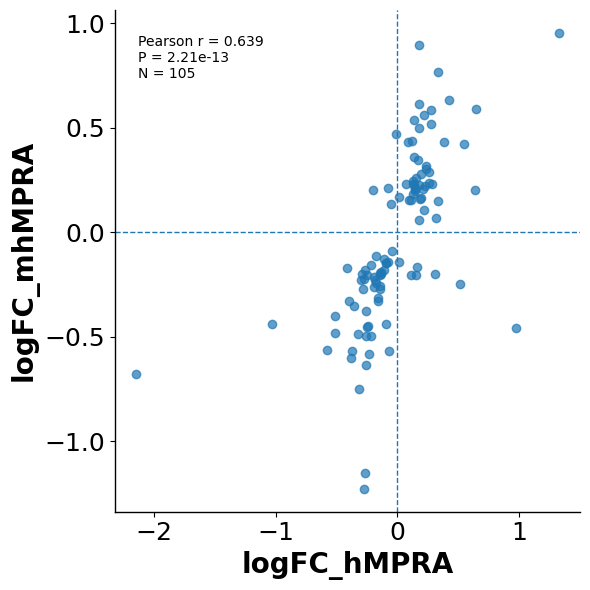

In [118]:

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

x = merged_collapsed["logFC_hMPRA"]
y = merged_collapsed["logFC_mhMPRA"]

# Remove rows with missing values in either column
valid = x.notna() & y.notna()
x = x[valid]
y = y[valid]

# Pearson correlation
r, p = pearsonr(x, y)

fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(
    x,
    y,
    alpha=0.7
)

# Dashed reference lines at x = 0 and y = 0
ax.axhline(0, linestyle="--", linewidth=1)
ax.axvline(0, linestyle="--", linewidth=1)

ax.set_xlabel("logFC_hMPRA")
ax.set_ylabel("logFC_mhMPRA")

# Add Pearson r and p-value to plot
ax.text(
    0.05, 0.95,
    f"Pearson r = {r:.3f}\nP = {p:.2e}\nN = {len(x)}",
    transform=ax.transAxes,
    va="top",
    ha="left"
)

plt.tight_layout()
plt.show()

In [119]:
import numpy as np

x_col = "logFC_hMPRA"
y_col = "logFC_mhMPRA"

direction_df = merged_collapsed[[x_col, y_col]].dropna().copy()

# Direction aligns if both values have the same sign:
# both positive or both negative
direction_df["direction_aligns"] = np.sign(direction_df[x_col]) == np.sign(direction_df[y_col])

# Optional: exclude cases where one or both values are exactly 0
direction_df = direction_df[
    (direction_df[x_col] != 0) & 
    (direction_df[y_col] != 0)
].copy()

n_total = len(direction_df)
n_aligned = direction_df["direction_aligns"].sum()
percent_aligned = 100 * n_aligned / n_total

print(f"Aligned direction: {n_aligned}/{n_total}")
print(f"Percent aligned: {percent_aligned:.2f}%")

Aligned direction: 94/105
Percent aligned: 89.52%
